# Encontro 2 - Insper AI - Classificadores e suas métricas

---
*Autor: Thomas Kassabian - Diretor da Insper AI*  
*Colaboradores: --*  
*Atualizado em: 09/2025*  

---

## Modelo de Classificação e Métricas de Desempenho de um Classificador

Este notebook aplica os conhecimentos do encontro anterior em um **problema de classificação** e aborda como avaliar o desempenho de um classificador. O dataset de câncer de mama de Wisconsin será utilizado para prever se um tumor é benigno ou maligno.

### Objetivo:
Desenvolver um modelo de classificação seguindo o workflow de ML e **aprender a avaliar o desempenho do modelo usando métricas apropriadas para classificação**.

### Etapas:
1. **Análise exploratória de Dados (EDA)**  
2. **Preparação dos Dados** 
3. **Implmentação e Treinamento do Modelo** 
4. **Previsões**
5. **Avaliação Crítica do Modelo** (Foco da atividade)

### Instruções:
- Consulte o notebook do último encontro caso tenha dúvidas em relação ao workflow.
- Após concluir, faça a atividade no notebook `lr-bgd.ipynb`.

---

## Antes de iniciar: uma boa prática essencial - Ambientes Virtuais

Um **ambiente virtual** é uma ferramenta que permite criar um espaço isolado dentro do sistema para instalar e gerenciar dependências de projetos Python. Em termos simples, é uma forma de criar uma "bolha" para cada um dos seus projetos.

### Por que usar ambientes virtuais?

Sem ambientes virtuais, todas as bibliotecas que você instala usando:
```bash
(pip install ...)
``` 
vão para um único lugar global no seu sistema. Isso causa dois grandes problemas:

- **Conflito de Versões**: Imagine que o Projeto A precisa da biblioteca scikit-learn==1.0. Meses depois, você inicia o Projeto B, que precisa de uma versão mais nova, a scikit-learn==1.5. Se você atualizar a biblioteca globalmente, o Projeto A pode quebrar. Isso é conhecido como "inferno das dependências" (dependency hell).

- **Reprodutibilidade**: Se você enviar seu projeto para um colega, como ele saberá exatamente quais versões de quais bibliotecas você usou? Um ambiente virtual permite exportar uma lista (requirements.txt) que recria o ambiente exato em qualquer outra máquina, garantindo que o código funcione da mesma forma.

### Vantagens dos ambientes virtuais

1. **Isolamento de Dependências**: Cada projeto pode ter suas próprias versões de bibliotecas, sem interferir em outros projetos.
2. **Reprodutibilidade**: Facilita a replicação do ambiente de desenvolvimento em outros sistemas.
3. **Organização**: Mantém o sistema global limpo, sem instalar pacotes desnecessários.

Os ambientes virtuais são uma prática altamente recomendada para qualquer projeto em Python, e devem ser criados no início do desenvolvimento.

### Como criar um ambiente virtual?

1. **Criar o ambiente**:
    ```bash
    python -m venv nome_do_ambiente 
    ```
    (normalmente, usa-se `"env"` ou `"venv"` como nome)

2. **Ativar o ambiente**:
    - No Windows:
      ```bash
      nome_do_ambiente\Scripts\activate
      ```
    - No macOS/Linux:
      ```bash
      source nome_do_ambiente/bin/activate
      ```

3. **Instalar dependências**:
    **Somente após** ativar o ambiente, use o `pip` para instalar pacotes:
    ```bash
    pip install nome_do_pacote
    ```

4. **Desativar o ambiente**:
    Para sair do ambiente virtual, use:
    ```bash
    deactivate
    ```

---

## Começando: Importando bibliotecas e carregando dados

Nessa atividade, usaremos as seguintes bibliotecas:
- **pandas**: Biblioteca para manipulação e análise de dados estruturados.
- **sklearn**: Biblioteca com ferramentas para Machine Learning, incluindo datasets, modelos e métricas.
- **matplotlib**: Biblioteca para criação de visualizações gráficas.

In [14]:
# Importar as bibliotecas necessárias
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [15]:
cancer = load_breast_cancer(as_frame=True)
df = cancer.frame

### Descrição do Dataset

O dataset utilizado nessa atividade é o conjunto de dados de câncer de mama de Wisconsin, que contém 569 amostras de tumores de mama, cada uma com 30 características numéricas, como textura, perímetro, área, etc. A variável alvo (`target`) é binária, indicando se o tumor é benigno (0) ou maligno (1).

### Definição do problema e objetivo

O objetivo é classificar os tumores como benignos ou malignos com base nas características extraídas de exames de imagem de aspiração por agulha fina (FNA) de tumores de mama.

---

## 1. Análise exploratória de Dados (EDA)

Explore a estrutura básica dos dados, crie visualizações e analise as relações, buscando:
- **Entender a estrutura dos dados**: dimensões, tipos de variáveis, valores faltantes
- **Analisar a distribuição das variáveis**: histogramas, estatísticas descritivas
- **Identificar relações entre variáveis**: correlações, scatter plots

Crie quantas células de código achar necessário para manter uma boa organização

In [16]:
# SEU CÓDIGO AQUI
import matplotlib.pyplot as plt

print(f"Shape do dataset: {df.shape}")
print("\nPrimeiras linhas:")
print(df.head())

print("\nResumo das colunas:")
resumo = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "unicos": df.nunique(),
})
print(resumo)

print("\nDistribuicao da variavel target:")
target_counts = df["target"].value_counts().sort_index()
target_labels = pd.Series(target_counts.values, index=["malignant (0)", "benign (1)"])
print(target_labels)

print("\nEstatisticas descritivas das features (resumo):")
stats = df.drop(columns=["target"]).describe().T[["mean", "std", "min", "50%", "max"]].round(2)
print(stats.head(10))

corr_target = (
    df.corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .head(8)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

target_labels.plot(kind="bar", ax=axes[0], color=["#c0392b", "#27ae60"])
axes[0].set_title("Distribuicao da target")
axes[0].set_ylabel("Contagem")
axes[0].tick_params(axis="x", rotation=15)

corr_target.sort_values().plot(kind="barh", ax=axes[1], color="#4c78a8")
axes[1].set_title("Features mais correlacionadas com a target")
axes[1].set_xlabel("Correlacao")

plt.tight_layout()
plt.show()

features_plot = ["mean radius", "mean texture", "mean perimeter", "mean area"]
df[features_plot].hist(bins=20, figsize=(12, 8), color="#6baed6", edgecolor="white")
plt.suptitle("Distribuicao de algumas features", y=1.02)
plt.tight_layout()
plt.show()


## 2. Preparação dos Dados

Separe o DataFrame em uma matriz de features (X) e um vetor target (y). Em seguida, dividir os dados em conjuntos de treino e teste:
1. Divida os dados em 80% para treino e 20% para teste
2. As variáveis resultantes devem ser: `X_train`, `X_test`, `y_train`, `y_test`
3. Exiba o tamanho de cada conjunto

In [17]:
# SEU CÓDIGO AQUI
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Treino: {X_train.shape}, Teste: {X_test.shape}')

Treino: (455, 30), Teste: (114, 30)


## 3. Implementação e Treinamento do Modelo

**Tarefa**: Instancie e treine um modelo de regressão logística (`LogisticRegression`) usando o *scikit-learn*. Além disso, **exiba os coeficientes e bias do modelo**.
- Utilize o parâmetro `max_iter=10000` para garantir a convergência do modelo (Você vai entender isso no outro notebook)

In [18]:
# SEU CÓDIGO AQUI
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

print("Coeficientes:")

for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef}")
print(f"Bias: {model.intercept_[0]}")

Coeficientes:
mean radius: 1.027436803336593
mean texture: 0.2214505054000141
mean perimeter: -0.36213488380572045
mean area: 0.0254667014198235
mean smoothness: -0.156235324092095
mean compactness: -0.23771255545593115
mean concavity: -0.5325578605476696
mean concave points: -0.28369224421619993
mean symmetry: -0.22668188523846416
mean fractal dimension: -0.036494462364261356
radius error: -0.09710207615387977
texture error: 1.3705666970168586
perimeter error: -0.1814094222040424
area error: -0.08719574741768957
smoothness error: -0.02245523103377289
compactness error: 0.047360921809598944
concavity error: -0.04294784123303201
concave points error: -0.03240188144834079
symmetry error: -0.034737324074110565
fractal dimension error: 0.011605215226101482
worst radius: 0.1116532864925189
worst texture: -0.5088772244264381
worst perimeter: -0.015553947678909089
worst area: -0.01685699621166072
worst smoothness: -0.30773116939737566
worst compactness: -0.7727090806929424
worst concavity: -1

## 4. Previsões

Com o modelo treinado:
1. Gere previsões para os dados teste
2. Crie um DataFrame comparando as previsões com os valores reais e exiba as primeiras previsões

In [19]:
# SEU CÓDIGO AQUI
y_test_pred = model.predict(X_test)

comparacao = pd.DataFrame({'Real': y_test, 'Predito': y_test_pred})
print(comparacao.head())

     Real  Predito
204     1        1
70      0        0
131     0        0
431     1        1
540     1        1


## 5. Avaliação Crítica do Modelo

Com o modelo treinado e as previsões feitas, a etapa mais importante é **avaliar sua qualidade**.

Para problemas de classificação, dado a natureza da variável target, são necessárias métricas diferentes das utilizadas em regressão de valores contínuos (último encontro).

### Métricas que vamos utilizar:
- **Acurácia**: Percentual de previsões corretas
- **Matriz de Confusão**: Visualização detalhada dos acertos e erros
- **Precisão**: Das previsões positivas, quantas estavam corretas?
- **Recall**: Dos casos positivos reais, quantos foram identificados?
- **F1-Score**: Média harmônica entre precisão e recall

### 5.1 Fronteira de Decisão: Visualizando o que o Modelo Aprendeu

Até agora, avaliamos o modelo através de métricas numéricas. No entanto, uma das formas mais intuitivas de entender o comportamento de um classificador é visualizar sua **fronteira de decisão**.

#### O que é uma Fronteira de Decisão?

A fronteira de decisão é a linha ou superfície que separa as regiões do espaço onde o modelo prevê classes diferentes. Para um problema binário, é literalmente a "fronteira" onde o modelo está mais indeciso sobre classificar uma amostra como classe 0 ou classe 1.

No caso da Regressão Logística, que prevê uma probabilidade ($\hat{p}$), a fronteira de decisão é o conjunto de todos os pontos onde a probabilidade prevista é exatamente **0.5**.

#### A Fronteira de Decisão na Regressão Logística

Lembre-se da equação do nosso modelo:

1.  Cálculo linear: $z = \mathbf{w}^T \cdot \mathbf{x} + b$
2.  Probabilidade: $\hat{p} = \sigma(z) = \frac{1}{1 + e^{-z}}$

A função sigmoide $\sigma(z)$ resulta em 0.5 apenas quando sua entrada $z$ é exatamente 0. Portanto, a fronteira de decisão para a Regressão Logística é o conjunto de todos os pontos $\mathbf{x}$ que satisfazem a equação:

$$ \mathbf{w}^T \cdot \mathbf{x} + b = 0 $$

Para um problema com duas features ($x_1, x_2$), essa é a equação de uma **linha reta**: $w_1x_1 + w_2x_2 + b = 0$. Para três features, é a equação de um plano, e assim por diante. É por isso que a Regressão Logística é conhecida como um **classificador linear**.

<div align="center">
<img src="https://codefinity-content-media.s3.eu-west-1.amazonaws.com/b71ff7ac-3932-41d2-a4d8-060e24b00129/DecisionBoundary.png" alt="Fronteira de decisão" width="600"/>
</div>

#### A Limitação da Linearidade

A grande vantagem e, ao mesmo tempo, a maior limitação da Regressão Logística é que sua fronteira de decisão é sempre linear.

Isso é suficiente para muitos problemas, mas e se a relação entre as classes for mais complexa, como um círculo ou uma curva sinuosa? Nenhuma linha reta conseguiria separar bem essas classes. Reflita sobre isso, será esclarecido no próximo encontro.

**Tarefa**: Como o modelo principal foi treinado com 30 features, nao conseguimos visualizar sua fronteira de decisao diretamente. Para contornar isso, escolha duas features (por exemplo, `mean radius` e `mean texture`), treine um **modelo auxiliar** de Regressao Logistica usando apenas essas duas features e plote sua fronteira de decisao.

**Dicas**:
- use `train_test_split(..., random_state=42)`
- monte uma grade de pontos com `np.meshgrid`
- use `predict_proba` na grade para localizar a fronteira em `0.5`
- plote os pontos de treino e a linha de contorno da fronteira


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

features_vis = ['mean radius', 'mean texture']
X_vis = df[features_vis]
y_vis = df['target']

X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis, y_vis, test_size=0.2, random_state=42
)

model_vis = LogisticRegression(max_iter=10000)
model_vis.fit(X_train_vis, y_train_vis)

x_min, x_max = X_train_vis.iloc[:, 0].min() - 1, X_train_vis.iloc[:, 0].max() + 1
y_min, y_max = X_train_vis.iloc[:, 1].min() - 1, X_train_vis.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=features_vis)
proba = model_vis.predict_proba(grid)[:, 1]
proba = proba.reshape(xx.shape)

cmap_bg = ListedColormap(['#f4a7a3', '#a8ddb5'])
cmap_pts = ListedColormap(['#c0392b', '#1e8449'])

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, proba >= 0.5, alpha=0.35, cmap=cmap_bg)
plt.contour(xx, yy, proba, levels=[0.5], colors='black', linewidths=2)
plt.scatter(
    X_train_vis.iloc[:, 0],
    X_train_vis.iloc[:, 1],
    c=y_train_vis,
    cmap=cmap_pts,
    edgecolor='k',
    s=35
)
plt.xlabel(features_vis[0])
plt.ylabel(features_vis[1])
plt.title('Fronteira de decisao - modelo auxiliar com 2 features')
plt.show()


### 5.2 Acurácia

A **acurácia** é a métrica mais básica para classificação. Ela responde à pergunta: "De todas as previsões, qual percentual estava correto?"

$$
\text{Acurácia} = \frac{\text{Número de Previsões Corretas}}{\text{Número Total de Previsões}}
$$

**Responda**: 
- Por que uma acurácia muito alta pode não necessariamente indicar um bom modelo em certos contextos?  

    **R**: Porque a acurácia não leva em conta a distribuição das classes. Em um conjunto de dados desbalanceado, um modelo pode simplesmente prever a classe majoritária e ainda assim obter uma alta acurácia, mesmo que não esteja aprendendo a identificar a classe minoritária.

**Tarefa**: Calcule a acurácia do modelo sem usar as funções prontas do sklearn.

In [20]:
#  SEU CÓDIGO AQUI
correct = sum(y_test == y_test_pred)
total = len(y_test)

accuracy = correct / total
print(f"Acurácia: {accuracy:.4f}")

Acurácia: 0.9561


### 5.3 Matriz de Confusão - Visualização Detalhada

A **Matriz de Confusão** é uma tabela que nos mostra exatamente onde o modelo está acertando e errando. A ideia é dividir as previsões em quatro categorias:

- **Verdadeiros Negativos (TN)**: O modelo previu negativo e o valor real é negativo.
- **Falsos Positivos (FP)**: O modelo previu positivo e o valor real é negativo.
- **Falsos Negativos (FN)**: O modelo previu negativo e o valor real é positivo.
- **Verdadeiros Positivos (TP)**: O modelo previu positivo e o valor real é positivo.

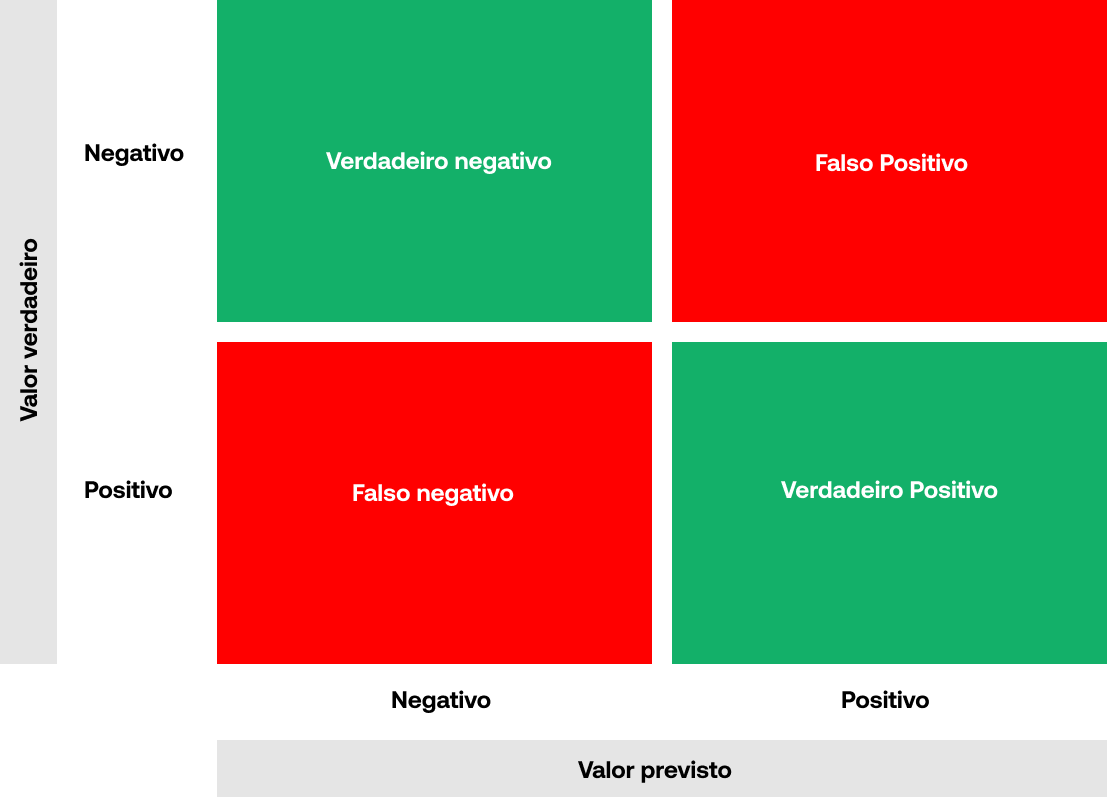

**Tarefa**: Gere a matriz de confusão do modelo usando o método `confusion_matrix` do scikit-learn e interprete os resultados

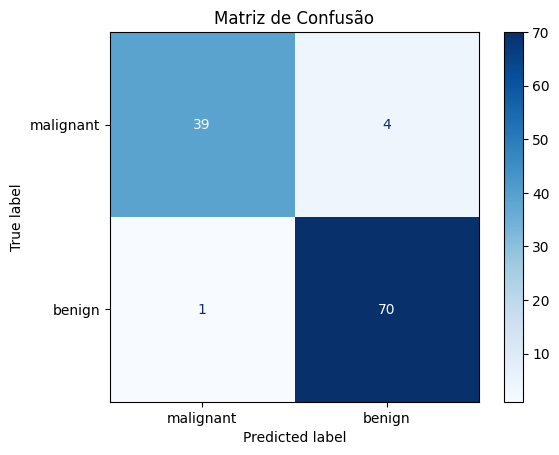

In [21]:
# SEU CÓDIGO AQUI
conf_matrix = confusion_matrix(y_test, y_test_pred)

# EXIBIÇÃO
import matplotlib.pyplot as plt
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=cancer.target_names)
disp.plot(cmap='Blues')
disp.ax_.set_title('Matriz de Confusão')
plt.show()

**Responda**:
- O que os valores na matriz indicam sobre o desempenho do modelo? Como se relaciona com a acurácia?  

    **R**:

### 5.4 Precisão e Recall - Métricas Cruciais

Para problemas de classificação, **Precisão** e **Recall** são métricas fundamentais:

#### **Precisão (Precision)**
A precisão mede a exatidão das previsões positivas do modelo, ou seja, ela responde à pergunta, no nosso contexto: "Das vezes que o modelo disse que é MALIGNO, quantas estavam corretas?"

$$\text{Precisão} = \frac{\text{TP}}{\text{TP} + \text{FP}}$$

- **Objetivo**: Minimizar falsos positivos (alarme falso)

- **Importância**: Situações onde o custo de um falso positivo é alto (ex: e-mail importante classificado como spam)

**Tarefa**: Calcule a precisão do modelo sem usar as funções prontas do sklearn.

In [22]:
# SEU CÓDIGO AQUI
TP = conf_matrix[1, 1]
FP = conf_matrix[0, 1]
TN = conf_matrix[0, 0]
FN = conf_matrix[1, 0]

precision = TP / (TP + FP)
print(f'Precision: {precision:.4f}')

Precision: 0.9459


**Responda**:
- O que uma precisão alta indica sobre o modelo? E um modelo com baixa precisão?  

    **R**:

#### **Recall (Sensibilidade)**
O recall mede a capacidade do modelo de identificar corretamente os casos positivos reais, ou seja, ele responde à pergunta, no nosso contexto: "De todos os casos MALIGNOS reais, quantos o modelo conseguiu identificar?"

$$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$

- **Objetivo**: Minimizar falsos negativos (perda de casos positivos)

- **Importância**: Situações onde o custo de um falso negativo é alto (ex: diagnóstico incorreto de doenças graves)

**Tarefa**: Calcule o recall do modelo sem usar as funções prontas do sklearn.

**Responda**:
- O que um alto recall indica sobre o modelo? E um modelo com baixo recall?  
    
    **R**:

In [23]:
# SEU CÓDIGO AQUI
recall = TP / (TP + FN)
print(f'Recall: {recall:.4f}')

Recall: 0.9859


**Responda**:
- No contexto do câncer de mama, qual métrica (precisão ou recall) você considera mais crítica? Justifique.  

    **R**:

### 5.5 F1-Score: Balanço Entre Precisão e Recall

#### 1. O Problema: Dilema Entre Precisão e Recall

Existe um trade-off natural entre Precisão e Recall:
* **Aumentar a Precisão** (ser mais rigoroso) geralmente diminui o Recall (deixa mais casos passarem).
* **Aumentar o Recall** (ser mais sensível) geralmente diminui a Precisão (gera mais alarmes falsos).

Isso cria um dilema: se você tem dois modelos, qual é o melhor?
* **Modelo A:** Precisão = 95%, Recall = 50%
* **Modelo B:** Precisão = 60%, Recall = 98%

A resposta depende do seu objetivo de negócio. Mas e se você não tiver uma preferência clara entre os dois tipos de erro? E se você simplesmente precisar de um modelo que seja "bom nos dois"? É aqui que o F1-Score entra.

#### 2. A Solução: Uma Métrica de Equilíbrio

O **F1-Score** é uma métrica que combina a Precisão e o Recall em um único número. Seu principal objetivo é fornecer uma medida do **equilíbrio** entre essas duas forças opostas.

Ele não é uma média simples, mas sim uma **média harmônica**. Isso porque a média harmônica **penaliza valores extremos de forma mais severa**. Dessa forma, um modelo só terá um F1-Score alto se ambos, Precisão e Recall, forem altos.

**Fórmula:**
$$F1 = 2 \cdot \frac{\text{Precisão} \cdot \text{Recall}}{\text{Precisão} + \text{Recall}}$$


#### 3. Quando Usar o F1-Score?

* **Cenário Ideal:** Use o F1-Score quando os custos de Falsos Positivos e Falsos Negativos são **similares** e você precisa de um balanço entre eles. É a métrica padrão para comparar o desempenho geral de modelos de classificação.

* **Cuidado:** **Não confie cegamente no F1-Score** se os custos dos erros forem drasticamente diferentes.
    * Se um **Falso Negativo for catastrófico** (ex: diagnóstico de doença), você deve focar primariamente no **Recall**.
    * Se um **Falso Positivo for muito prejudicial** (ex: filtro de spam deletando um e-mail importante), você deve focar primariamente na **Precisão**.

Em resumo, o F1-Score é a sua melhor métrica "padrão" para avaliar um classificador, mas ele nunca deve ser olhado de forma isolada.

**Tarefa**: Calcule e exiba o F1-Score do modelo sem usar as funções prontas do sklearn.

In [24]:
# SEU CÓDIGO AQUI

F1 = 2 * (precision * recall) / (precision + recall)
print(f'F1-Score: {F1:.4f}')

F1-Score: 0.9655


**Responda**:
- Em que situações o F1-Score é uma métrica mais apropriada do que precisão ou recall isoladamente?  

    **R**:

### 5.6 Interprete os Resultados

**Tarefa**: Com base na matriz de confusão, na acurácia, na precisão, no recall, no F1-Score e na fronteira de decisão, escreva uma interpretação curta do desempenho do modelo.

**Responda**:
- O modelo parece equilibrado entre precisão e recall?  
- Os erros observados parecem aceitáveis para esse problema?  
- O que a fronteira de decisão sugere sobre a capacidade do modelo?  
- Se você fosse melhorar esse classificador, qual seria o próximo passo?  

    **R**:

## 6. Conclusão 

Neste notebook, você aplicou o workflow completo de Machine Learning para construir e, principalmente, avaliar criticamente um modelo de classificação. Utilizando a biblioteca `scikit-learn`, uma Regressão Logística foi treinada e o foco principal foi a análise de sua performance através de métricas específicas para classificação.

**Principais Aprendizados:**

* **Insuficiência da Acurácia:** Ficou demonstrado que a **Acurácia**, apesar de intuitiva, é uma métrica enganosa em cenários com classes desbalanceadas, podendo mascarar um modelo com baixo poder preditivo para a classe de interesse.

* **Diagnóstico com a Matriz de Confusão:** A **Matriz de Confusão** é a ferramenta fundamental para diagnosticar o comportamento de um classificador. Ela detalha os tipos de acertos e erros, permitindo o cálculo de métricas mais robustas.

* **O Trade-off de Precisão e Recall:** **Precisão** e **Recall** são métricas essenciais que possuem um trade-off. A otimização de uma geralmente impacta a outra, e a escolha da métrica prioritária depende diretamente do **custo do erro** associado ao problema de negócio (ex: diagnóstico médico vs. filtro de spam).

* **F1-Score como Métrica de Equilíbrio:** O **F1-Score** funciona como uma média harmônica que combina Precisão e Recall. Ele é útil para comparar o desempenho geral de modelos de forma balanceada, especialmente quando não há uma preferência clara entre os tipos de erro.

O próximo passo em nossa trilha é superar a limitação dos modelos lineares. No encontro seguinte, utilizaremos o conhecimento sobre avaliação de classificadores como base para construir **Redes Neurais**, modelos capazes de aprender fronteiras de decisão complexas para resolver problemas mais desafiadores.

## 7. Desafio (obrigatório)
Implemente manualmente um classificador binário usando Regressão Logística e Gradiente Descendente. Utilize o dataset de câncer de mama de Wisconsin para treinar e avaliar seu modelo. Compare os resultados com o modelo do scikit-learn.

Faça a atividade no notebook `lr-bgd.ipynb`.